In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# CHANGE THESE TWO VALUES for the supplied classification dataset.

TARGET_COLUMN = "has_heart_disease"

df = pd.read_csv(r"C:\Users\Samaira Singh\Synergy_TP\task_9.5\data\heart_disease_risk_2026.csv")
print("Shape:", df.shape)
display(df.head())
print(df.info())


Shape: (9000, 27)


,patient_id,age,sex,resting_bp_systolic,resting_bp_diastolic,cholesterol_total,hdl,ldl,triglycerides,fasting_blood_sugar,...,family_history,smoker_status,alcohol_units_per_week,exercise_minutes_per_week,sleep_hours,stress_score,wearable_owner,daily_steps,diet_quality_score,has_heart_disease
0,1,44,Male,117,74,193,57,106,119,112,...,False,Never,2.9,86,5.4,19.8,True,7731,62.9,0
1,2,57,Male,139,94,185,69,110,35,114,...,False,Never,3.0,132,4.3,45.8,True,2629,74.6,1
2,3,29,Male,128,78,197,52,108,157,95,...,False,Current,3.5,128,5.1,17.7,True,9290,65.7,0
3,4,72,Male,132,86,197,59,104,143,92,...,False,Never,2.7,18,6.8,63.6,True,7373,48.5,1
4,5,62,Female,116,75,154,65,75,104,135,...,True,Former,3.3,24,8.2,58.7,False,6331,47.3,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   patient_id                 9000 non-null   int64  
 1   age                        9000 non-null   int64  
 2   sex                        9000 non-null   object 
 3   resting_bp_systolic        9000 non-null   int64  
 4   resting_bp_diastolic       9000 non-null   int64  
 5   cholesterol_total          9000 non-null   int64  
 6   hdl                        9000 non-null   int64  
 7   ldl                        9000 non-null   int64  
 8   triglycerides              9000 non-null   int64  
 9   fasting_blood_sugar        9000 non-null   int64  
 10  hba1c                      9000 non-null   float64
 11  bmi                        9000 non-null   float64
 12  resting_heart_rate         9000 non-null   int64  
 13  max_heart_rate_achieved    9000 non-null   int64

In [2]:
print("Missing values:")
print(df.isna().sum())

print("\nTarget distribution:")
print(df[TARGET_COLUMN].value_counts(dropna=False))

print("\nSummary:")
print(df.describe(include="all"))


Missing values:
patient_id                   0
age                          0
sex                          0
resting_bp_systolic          0
resting_bp_diastolic         0
cholesterol_total            0
hdl                          0
ldl                          0
triglycerides                0
fasting_blood_sugar          0
hba1c                        0
bmi                          0
resting_heart_rate           0
max_heart_rate_achieved      0
chest_pain_type              0
exercise_induced_angina      0
st_depression                0
family_history               0
smoker_status                0
alcohol_units_per_week       0
exercise_minutes_per_week    0
sleep_hours                  0
stress_score                 0
wearable_owner               0
daily_steps                  0
diet_quality_score           0
has_heart_disease            0
dtype: int64

Target distribution:
has_heart_disease
0    6273
1    2727
Name: count, dtype: int64

Summary:
         patient_id          age   sex

In [3]:
# Prepare X and binary y.
# This assumes the target is already encoded as 0 and 1.
# Select numeric features and target
X_df = df.select_dtypes(include="number").drop(columns=[TARGET_COLUMN])

X = X_df.to_numpy(dtype=float)
y = df[TARGET_COLUMN].to_numpy(dtype=float).reshape(-1, 1)

print("Classes:", np.unique(y))
print("X shape:", X.shape)
print("y shape:", y.shape)

Classes: [0. 1.]
X shape: (9000, 20)
y shape: (9000, 1)


In [4]:
# Our own train/validation/test split
def train_val_test_split(X, y, val_size=0.15, test_size=0.15):
    np.random.seed(42)
    idx = np.arange(len(X))
    np.random.shuffle(idx)
    n_train = int(len(X) * (1 - val_size - test_size))
    n_val = int(len(X) * val_size)
    tr, va, te = idx[:n_train], idx[n_train:n_train + n_val], idx[n_train + n_val:]

    return X[tr], y[tr], X[va], y[va], X[te], y[te]

X_train, y_train, X_val, y_val, X_test, y_test = train_val_test_split(X, y)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)


Train: (6300, 20) (6300, 1)
Validation: (1350, 20) (1350, 1)
Test: (1350, 20) (1350, 1)


In [5]:
# Standardization using training statistics only
def fit_standard_scaler(X):
    mean = X.mean(axis=0)
    std = X.std(axis=0)
    std[std == 0] = 1.0
    return mean, std

def transform_standard_scaler(X, mean, std):
    return (X - mean) / std

X_mean, X_std = fit_standard_scaler(X_train)

X_train_s = transform_standard_scaler(X_train, X_mean, X_std)
X_val_s = transform_standard_scaler(X_val, X_mean, X_std)
X_test_s = transform_standard_scaler(X_test, X_mean, X_std)


In [6]:
def sigmoid(z):
    # Clip values to avoid overflow in exp for extreme scores.
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

def predict_proba(X, w, b):
    return sigmoid(X @ w + b)

def predict_class(X, w, b, threshold=0.5):
    probabilities = predict_proba(X, w, b)
    return (probabilities >= threshold).astype(int)

def binary_cross_entropy(y_true, y_prob):
    eps = 1e-12
    y_prob = np.clip(y_prob, eps, 1 - eps)
    return -np.mean(
        y_true * np.log(y_prob) +
        (1 - y_true) * np.log(1 - y_prob)
    )

def logistic_gradient_descent(X_train, y_train, X_val, y_val,
                              learning_rate=0.05, iterations=2000):
    m, n = X_train.shape
    w = np.zeros((n, 1))
    b = 0.0

    train_losses = []
    val_losses = []

    for _ in range(iterations):
        probabilities = predict_proba(X_train, w, b)
        error = probabilities - y_train

        dw = (X_train.T @ error) / m
        db = np.mean(error)

        w -= learning_rate * dw
        b -= learning_rate * db

        train_losses.append(
            binary_cross_entropy(y_train, predict_proba(X_train, w, b))
        )
        val_losses.append(
            binary_cross_entropy(y_val, predict_proba(X_val, w, b))
        )

    return w, b, train_losses, val_losses

w, b, train_losses, val_losses = logistic_gradient_descent(
    X_train_s, y_train, X_val_s, y_val,
    learning_rate=0.05,
    iterations=2000
)

print("Weights:", w.ravel())
print("Bias:", b)


Weights: [ 0.0689068  -0.81113633  0.18068581 -0.06435029  0.08294999 -0.51149671
  0.42164377  0.0051018   0.02606361  0.30998984  0.14480462  0.21249601
 -2.35678889  0.80595537  0.14895236  0.09837531 -0.0878522   0.12632008
 -0.12585009 -0.20223962]
Bias: -1.566842417903013


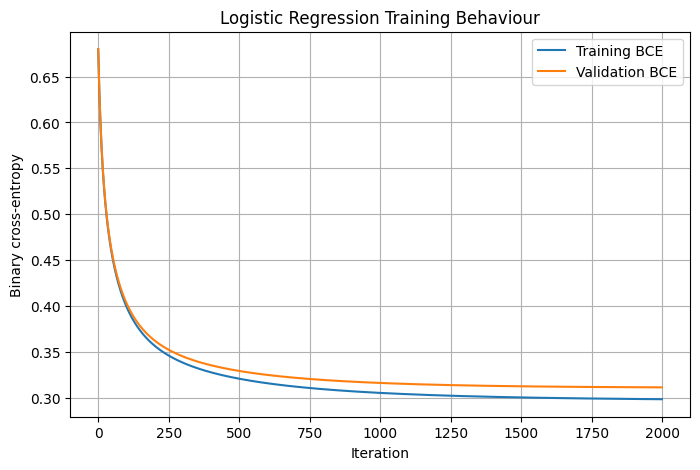

In [ ]:
# visualisation
plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Training BCE")
plt.plot(val_losses, label="Validation BCE")
plt.xlabel("Iteration")
plt.ylabel("Binary cross-entropy")
plt.title("Logistic Regression Training Behaviour")
plt.legend()
plt.grid(True)
plt.show()


In [8]:
# Manual classification metrics
def confusion_matrix_manual(y_true, y_pred):
    y_true = y_true.ravel().astype(int)
    y_pred = y_pred.ravel().astype(int)

    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    return np.array([[tn, fp],
                     [fn, tp]])

def classification_metrics(y_true, y_pred):
    cm = confusion_matrix_manual(y_true, y_pred)
    tn, fp = cm[0]
    fn, tp = cm[1]

    accuracy = (tp + tn) / max(tp + tn + fp + fn, 1)
    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-12)

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "TN": tn, "FP": fp, "FN": fn, "TP": tp
    }

threshold = 0.5
splits = [("Train", X_train_s, y_train), ("Validation", X_val_s, y_val), ("Test", X_test_s, y_test)]

for name, X_part, y_part in splits:
    preds = predict_class(X_part, w, b, threshold)
    
    print(f"\n{name}\n" + "-" * len(name))
    for metric, value in classification_metrics(y_part, preds).items():
        print(f"{metric}: {value:.4f}")


Train
-----
Accuracy: 0.8706
Precision: 0.8164
Recall: 0.7390
F1: 0.7758
TN: 4075.0000
FP: 317.0000
FN: 498.0000
TP: 1410.0000

Validation
----------
Accuracy: 0.8704
Precision: 0.8223
Recall: 0.7416
F1: 0.7799
TN: 865.0000
FP: 67.0000
FN: 108.0000
TP: 310.0000

Test
----
Accuracy: 0.8733
Precision: 0.8402
Recall: 0.7082
F1: 0.7686
TN: 895.0000
FP: 54.0000
FN: 117.0000
TP: 284.0000


Confusion Matrix:
TN: 895  FP: 54
FN: 117  TP: 284


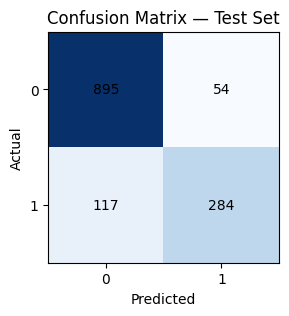

In [10]:
# Display the test confusion matrix

test_pred = predict_class(X_test_s, w, b, threshold)
cm = confusion_matrix_manual(y_test, test_pred)

print("Confusion Matrix:")
print(f"TN: {cm[0,0]}  FP: {cm[0,1]}")
print(f"FN: {cm[1,0]}  TP: {cm[1,1]}")

plt.figure(figsize=(4, 3))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix — Test Set")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0, 1])
plt.yticks([0, 1])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

In [11]:
# majority class from training data (0 or 1)
majority_class = int(np.mean(y_train) >= 0.5)
print("Majority class:", majority_class)

# baseline predictions filled with majority class
base_train = np.full_like(y_train, majority_class)
base_val = np.full_like(y_val, majority_class)
base_test = np.full_like(y_test, majority_class)

# performance across splits
baseline_metrics = pd.DataFrame([
    classification_metrics(y_train, base_train),
    classification_metrics(y_val, base_val),
    classification_metrics(y_test, base_test)
], index=["Train", "Validation", "Test"])

display(baseline_metrics)

# Logistic Regression model vs Baseline on Test set
comparison = pd.DataFrame([
    classification_metrics(y_test, test_pred),
    classification_metrics(y_test, base_test)
], index=["Logistic Regression", "Majority Baseline"])

display(comparison)

Majority class: 0


,Accuracy,Precision,Recall,F1,TN,FP,FN,TP
Train,0.697143,0.0,0.0,0.0,4392,0,1908,0
Validation,0.690370,0.0,0.0,0.0,932,0,418,0
Test,0.702963,0.0,0.0,0.0,949,0,401,0


,Accuracy,Precision,Recall,F1,TN,FP,FN,TP
Logistic Regression,0.873333,0.840237,0.708229,0.768606,895,54,117,284
Majority Baseline,0.702963,0.000000,0.000000,0.000000,949,0,401,0


,Threshold,Precision,Recall,F1
0,0.10,0.534045,0.956938,0.685518
1,0.15,0.589744,0.935407,0.723404
2,0.20,0.635294,0.904306,0.746298
3,0.25,0.666065,0.882775,0.759259
4,0.30,0.710372,0.868421,0.781485
5,0.35,0.747845,0.830144,0.786848
6,0.40,0.777778,0.803828,0.790588
7,0.45,0.799007,0.770335,0.784409
8,0.50,0.822281,0.741627,0.779874
9,0.55,0.844380,0.700957,0.766013


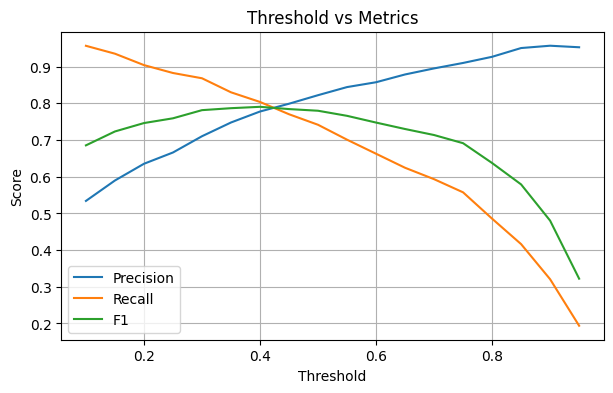

In [14]:
# Evaluate metrics across thresholds
rows = []
for t in np.arange(0.1, 1.0, 0.05):
    preds = predict_class(X_val_s, w, b, t)
    m = classification_metrics(y_val, preds)
    rows.append({"Threshold": t, "Precision": m["Precision"], "Recall": m["Recall"], "F1": m["F1"]})

df = pd.DataFrame(rows)
display(df)

plt.figure(figsize=(7, 4))
plt.plot(df["Threshold"], df["Precision"], label="Precision")
plt.plot(df["Threshold"], df["Recall"], label="Recall")
plt.plot(df["Threshold"], df["F1"], label="F1")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold vs Metrics")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# False-positive / false-negative inspection
#Flatten arrays to 1D
probs = predict_proba(X_test_s, w, b).flatten()
y_true = y_test.flatten()
y_pred = test_pred.flatten()

df_errors = pd.DataFrame({
    "Actual": y_true,
    "Predicted": y_pred,
    "Probability": probs,
    "Error_Type": np.where(y_true < y_pred, "False Positive", "False Negative")
})

errors = df_errors[y_true != y_pred]

print("Misclassified test examples:")
print(errors.head(20))


Misclassified test examples:
     Actual  Predicted  Probability      Error_Type
4       1.0          0     0.485109  False Negative
20      0.0          1     0.750398  False Positive
27      1.0          0     0.481545  False Negative
30      1.0          0     0.298445  False Negative
35      0.0          1     0.522815  False Positive
40      0.0          1     0.706610  False Positive
50      1.0          0     0.234620  False Negative
53      1.0          0     0.198267  False Negative
85      0.0          1     0.884081  False Positive
97      1.0          0     0.270596  False Negative
110     1.0          0     0.421064  False Negative
121     0.0          1     0.629880  False Positive
132     1.0          0     0.081494  False Negative
146     1.0          0     0.306942  False Negative
148     1.0          0     0.470846  False Negative
168     1.0          0     0.223771  False Negative
173     0.0          1     0.550945  False Positive
175     0.0          1     0.611132